# Lecture 6 – NumPy and SciPy

Al Jay Lan ALAMIN

**Scientific Python | QLS Diploma Programme**

## Lecture objectives
- Import scientific Python libraries.
- Compare Python lists and NumPy arrays.
- Create, inspect, index, slice, and manipulate multidimensional arrays.
- Apply element-wise operations, broadcasting, and vectorisation.
- Use statistics, Boolean masks, linear algebra, and random number generation.
- SciPy numerical integration and interpolation 


# Part I: NumPy

**Documentation:** [NumPy User Guide](https://numpy.org/doc/stable/user/) · [NumPy API Reference](https://numpy.org/doc/stable/reference/)

NumPy is an external Python library used for vectorised or array computations.

A generalised vector containing $n$ elements is represented by list of identical objects: 

$$\mathbf{v}=(v_0,v_1,\ldots,v_{n-1}).$$

A matrix is a multi-dimensional array with $m$ rows and $n$ columns is represented by:

$$A_{ij}=\begin{pmatrix}A_{00}&A_{01}&\cdots&A_{0,n-1}\\ A_{10}&A_{11}&\cdots&A_{1,n-1}\\ \vdots&\vdots&\ddots&\vdots\\ A_{m-1,0}&A_{m-1,1}&\cdots&A_{m-1,n-1}\end{pmatrix}$$

where $A_{ij}$ denotes the element in row $i$ and column $j$.


## Importing external libraries

External libraries must be imported before their functions and classes can be used.

| Syntax | Description |
|---|---|
| `import numpy` | Imports the NumPy package |
| `import numpy as np` | Imports NumPy using an alias |
| `from numpy import zeros` | Imports a specific function |
| `help(np.array)` | Displays documentation for a function |
| `dir(np)` | Lists names available in the module |

The general syntax is 


```python
import LIBRARY as PREFIX
```
Functions and other objects are then accessed as 

```python
PREFIX.function()
```

In [1]:
# Import NumPy using its conventional alias
import numpy as np

# Create an array containing two zeros
x = np.zeros(2)

# Display the result
print(x)

[0. 0.]


The syntax 

```python
from LIBRARY import FUNCTION
```

imports an individual function. The library prefix is then unnecessary when calling it.

In [2]:
# Import the zeros function directly from NumPy
from numpy import zeros

# Call the imported function without the np prefix
x = zeros(2)

# Display the result
print(x)

[0. 0.]


A prefix avoids name conflicts when multiple libraries provide similarly named functions. 


For example, `math` and `numpy` both provide `sqrt()`, `sin()` and `cos()`.

- `math` functions generally operate on scalar numbers.
- `numpy` functions can operate element-wise on arrays.

In [3]:
# Import two libraries with similarly named functions
import math
import numpy as np

# Compare the square root of a scalar
x = 4
print(math.sqrt(x))
print(np.sqrt(x))

# Define an array of four numbers
A = np.array([1, 4, 9, 16])

# NumPy applies the function to each array element
print(np.sqrt(A))

# math.sqrt expects a scalar, not a multidimensional array
# print(math.sqrt(A))  # TypeError

2.0
2.0
[1. 2. 3. 4.]


## General properties of NumPy arrays

NumPy arrays share several properties with Python lists but differ in how they organise and process numerical data.

| Property | Python list | NumPy array |
|---|---|---|
| Iterable | Yes | Yes |
| Indexed | Yes | Yes |
| Ordered | Yes | Yes |
| Mutable | Yes | Yes, when writeable |
| Slicable | Yes | Yes, along multiple axes |
| Homogeneous | Not required | Common `dtype` |
| Multidimensional | Nested lists | Native multidimensional arrays |
| Size | Can grow using `.append()` | Generally fixed; `np.append()` creates a new array |
| Vectorised arithmetic | Not built in | Yes |
| Broadcasting | No | Yes |



## 1. NumPy array attributes

NumPy arrays have built-in attributes that describe their structure and data type. These attributes can be accessed using dot notation without parentheses.

| Attribute | Description | Example |
|---|---|---|
| `A.ndim` | Number of dimensions (axes) | `2` |
| `A.shape` | Number of elements along each axis | `(2, 3)` |
| `A.size` | Total number of elements | `6` |
| `A.dtype` | Data type of the elements | `int64` (platform-dependent) |



## 2. Creating arrays

NumPy provides several functions for creating arrays without manually specifying every element. These functions are useful for initialising data, discretising mathematical domains, and constructing matrices for numerical calculations.

| Function | Description | Application |
|---|---|---|
| `np.array(sequence)` | Creates an array from existing data | Convert experimental measurements or Python lists into arrays |
| `np.zeros(shape)` | Creates an array filled with zeros | Initialise particle positions or numerical results |
| `np.ones(shape)` | Creates an array filled with ones | Initialise uniform values or coefficients |
| `np.full(shape, value)` | Creates an array filled with a specified value | Assign the same initial temperature or density to every grid point |
| `np.arange(start, stop, step)` | Creates values using a specified **step size**; excludes `stop` | Generate indices or sequences with a fixed increment |
| `np.linspace(start, stop, num)` | Creates a specified **number of equally spaced points**; includes `stop` by default | Discretise a spatial or temporal domain, including its endpoints |
| `np.eye(n)` | Creates an $n\times n$ identity matrix | Linear algebra and matrix calculations |





**Example: Array attributes**





In [4]:
import numpy as np


# Define a 2-D NumPy array
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# Inspect the array attributes
print(A.ndim)   # Number of dimensions
print(A.shape)  # Shape of the array
print(A.size)   # Total number of elements
print(A.dtype)  # Data type of the elements



2
(2, 3)
6
int64



**Note:** Attributes describe an array, whereas methods such as `A.reshape()` and `A.copy()` perform operations on it.




In [5]:

import numpy as np

# Define the original array
A = np.array([1, 2, 3])
# Append two elements to create a new array
B = np.append(A, [4, 5])

print(A)  # [1 2 3]
print(B)  # [1 2 3 4 5]


[1 2 3]
[1 2 3 4 5]


In [6]:

# Define a 2-D array
A = np.array([[1, 2],
              [3, 4]])

# Append a new row along axis 0
B = np.append(A, [[5, 6]], axis=0) #adds row into a new array

print(A.shape)
print(B.shape)  # (3, 2)


(2, 2)
(3, 2)



### Specifying array data types

NumPy automatically determines the data type (`dtype`) of an array from its elements. Alternatively, the data type can be specified explicitly using the `dtype` argument.

| Data type | Description |
|---|---|
| `int` | Integer |
| `float` | Floating-point number |
| `bool` | Boolean (`True` or `False`) |
| `str` | String |
| `np.int32`, `np.int64` | Integers with specified precision |
| `np.float32`, `np.float64` | Floating-point numbers with specified precision |





### Example: Specifying NumPy Array Type



In [7]:

import numpy as np

# NumPy automatically infers the data type
A = np.array([1, 2, 3])
print(A.dtype)

# Explicitly specify floating-point values
B = np.array([1, 2, 3], dtype=float)
print(B)
print(B.dtype)

# Specify 32-bit floating-point values
C = np.array([1, 2, 3], dtype=np.float32)
print(C.dtype)

# Convert an existing array to another data type
D = A.astype(float)
print(D)
print(D.dtype)

# Convert floating-point values to integers
# The fractional part is discarded
E = np.array([1.5, 2.8, 3.2], dtype=int)
print(E)

# Mixed numerical types are converted to a common type
F = np.array([1, 2.5, 3])
print(F)
print(F.dtype)



int64
[1. 2. 3.]
float64
float32
[1. 2. 3.]
float64
[1 2 3]
[1.  2.5 3. ]
float64


 **Important:** 

1. When elements of different numerical types are provided, NumPy generally converts them to a compatible type. 
 
2. Explicit conversion to an integer type discards the fractional part rather than rounding.


### Example:  Efficiency NumPy vs. math and for-Loop:

In [8]:

import math
import numpy as np

N = 50000

# Method 1: Python for loop using math.exp()
def exponential_loop(n):
    """Return a list of n exponential values using a for loop."""
    xs = np.linspace(0, 1, n)
    ys = []

    for x in xs:
        ys.append(math.exp(x))

    return ys


# Method 2: Python list comprehension using math.exp()
def exponential_list(n):
    """Return a list of n exponential values using list comprehension."""
    xs = np.linspace(0, 1, n)

    return [math.exp(x) for x in xs]


# Method 3: NumPy vectorisation using np.exp()
def exponential_numpy(n):
    """Return an array of n exponential values using NumPy."""
    xs = np.linspace(0, 1, n)

    return np.exp(xs)


# Verify that all three methods produce the same values
print(np.allclose(exponential_loop(N), exponential_list(N)))
print(np.allclose(exponential_loop(N), exponential_numpy(N)))

# Compare execution times using Jupyter's timeit magic
print("Python for loop:")
%timeit exponential_loop(N)

print("Python list comprehension:")
%timeit exponential_list(N)

print("NumPy vectorisation:")
%timeit exponential_numpy(N)


True
True
Python for loop:
3.17 ms ± 272 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Python list comprehension:
2.91 ms ± 182 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
NumPy vectorisation:
203 μs ± 7.69 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Example: Python list versus NumPy array

In [9]:
# Run this example to explore the numerical operations described above.
import numpy as np

# Define a Python list and a NumPy array
L = [1, 2, 3]
A = np.array([1, 2, 3])

# Inspect their types
print(type(L))
print(type(A))

# Both are indexed: access the first element
print(L[0])
print(A[0])

# Both are mutable: change the first element
L[0] = 10
A[0] = 10
print(L)
print(A)

# List multiplication repeats the list
print(L * 2)

# NumPy multiplication acts on each element
print(A * 2)

# Python lists can grow in place
L.append(4)

# np.append returns a new array; A stays unchanged
B = np.append(A, 4)
print(L)
print(A)
print(B)

<class 'list'>
<class 'numpy.ndarray'>
1
1
[10, 2, 3]
[10  2  3]
[10, 2, 3, 10, 2, 3]
[20  4  6]
[10, 2, 3, 4]
[10  2  3]
[10  2  3  4]


**Key distinction:** 


NumPy arrays also support element-wise numerical operations without requiring explicit Python loops.





### Example: Calculating particle kinetic energy

Consider a collection of particles with different masses and velocities. The kinetic energy of each particle is

$$
E_{k,i}=\frac{1}{2}m_i v_i^2.
$$

Calculate the kinetic energy of each particle using both a Python list and a NumPy array. 


In [10]:

import numpy as np

# Define particle masses (kg) and velocities (m/s)
mass = [1.0, 1.5, 2.0, 2.5]
velocity = [2.0, 3.0, 4.0, 5.0]

# Method 1: Python lists
# Iterate over corresponding mass and velocity values
energy_list = []

for m, v in zip(mass, velocity):
    energy_list.append(0.5 * m * v**2)

print("Python list:", energy_list)


Python list: [2.0, 6.75, 16.0, 31.25]


In [11]:

# Method 2: NumPy arrays
# Convert the lists to NumPy arrays
m = np.array(mass)
v = np.array(velocity)

# Calculate kinetic energy element-wise
energy_array = 0.5 * m * v**2

print("NumPy array:", energy_array)


NumPy array: [ 2.    6.75 16.   31.25]



### Exercise: Particle momentum

Modify the example to calculate the momentum of each particle:

$$
p_i=m_i v_i.
$$

1. Calculate the momentum using Python lists and NumPy arrays.


In [12]:
# import numpy
import numpy as np

def momentum_list(
        mass,
        velocity):

    # initialize list for momentum
    momentum_list = []

    for m, v in zip(mass, velocity):
        momentum_list.append(m*v)

    # print(momentum_list)

    return momentum_list

def momentum_numpy(
        mass,
        velocity):

    # convert lists to np.arrays
    m = np.array(mass)
    v = np.array(velocity)

    # print(momentum_array)

    return m * v

# Define particle masses (kg) and velocities (m/s)
mass = [1.0, 1.5, 2.0, 2.5]
velocity = [2.0, 3.0, 4.0, 5.0]

m_list = momentum_list(mass, velocity)
m_array = momentum_numpy(mass, velocity)

# prints results
print(m_list)
print(m_array)

# checks if they are equal
print(np.allclose(m_list, m_array))

print("Using python lists:")
%timeit momentum_list(mass, velocity)

print("Using numpy:")
%timeit momentum_numpy(mass, velocity)    

# weird result on the efficiency of numpy but numpy's efficiency is better illustrated if
# we define particle masses (kg) and velocities (m/s)
# mass = np.random.random(100)
# velocity = np.random.random(100)

[2.0, 4.5, 8.0, 12.5]
[ 2.   4.5  8.  12.5]
True
Using python lists:
227 ns ± 2.21 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Using numpy:
757 ns ± 14.7 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


### Example: Initialising a numerical simulation

Suppose we want to simulate the motion of 100 particles over 50 time steps.



In [13]:
import numpy as np

# Number of particles and time steps
N = 100
nt = 50

# Initialise particle positions to zero
position = np.zeros((N, nt))

# Assign the same initial velocity to all particles
velocity = np.full(N, 5.0)

# Create a time array from 0 to 10 seconds
# with exactly 50 points
time = np.linspace(0, 10, nt)

# Generate particle indices
particle_id = np.arange(N)

# Inspect the resulting arrays
print(position.shape)
print(velocity.shape)
print(time.shape)
print(particle_id.shape)

(100, 50)
(100,)
(50,)
(100,)



**Important:** Use `np.arange()` when the increment is specified, and `np.linspace()` when the number of points and inclusion of both endpoints are important.


### Exercise: Creating NumPy arrays from Python collections

The following datasets contain temperature measurements, particle trajectories, and experimental data stored in different Python collections.

**Tasks:**

1. Convert each dataset into a NumPy array using `np.array()`.
2. Inspect the following attributes:
   - `ndim`: Number of dimensions.
   - `shape`: Shape of the array.
   - `size`: Total number of elements.
   - `dtype`: Data type of the elements.

#### Dataset 1: Temperature measurements

```python
import numpy as np
# Fixed step size: 2 seconds
# The endpoint 10 is excluded
t1 = np.arange(0, 10, 2)

# Fixed number of points: 6
# Both endpoints are included
t2 = np.linspace(0, 10, 6)

print(t1)  # [0 2 4 6 8]
print(t2)  # [ 0.  2.  4.  6.  8. 10.]



# Temperature measurements (K)
temperature = [
    298.4, 299.1, 300.2, np.nan, 301.5,
    299.8, 300.6, 301.1, np.nan, 298.9,
    299.7, 300.4, 302.1, 301.6, np.nan,
    300.1, 299.5, 300.8, 301.3, 299.9
]

# Convert the list into a NumPy array


# Inspect the array attributes

```

#### Dataset 2: Particle trajectories

```python
# Particle trajectories
trajectories = [
    [0.0, 0.4, 0.9, 1.3, 1.8, 2.1, 2.5, 2.9],
    [0.0, -0.3, -0.7, np.nan, -1.4, -1.8, -2.0, -2.4],
    [0.0, 0.2, 0.6, 1.1, 1.5, np.nan, 2.4, 2.8],
    [0.0, -0.5, -0.8, -1.0, -1.4, -1.7, -2.1, -2.6],
    [0.0, 0.6, 1.0, 1.7, np.nan, 2.6, 3.1, 3.5],
    [0.0, -0.2, -0.4, -0.7, -0.9, -1.1, np.nan, -1.6]
]

# Convert the nested list into a NumPy array


# Inspect the array attributes

```

#### Dataset 3: Experimental measurements

```python
# Experimental measurements
experiments = [
    ["run_1", 300, [1.21, 1.18, np.nan, 1.25, 1.23, 1.19, 1.27]],
    ["run_2", 350, [1.46, 1.51, 1.48, np.nan, 1.55, 1.52, 1.49]],
    ["run_3", 400, [1.82, np.nan, 1.79, 1.88, 1.85, 1.91, 1.86]],
    ["run_4", 450, [2.13, 2.18, 2.09, 2.21, np.nan, 2.16, 2.20]],
    ["run_5", 500, [2.45, 2.51, np.nan, 2.48, 2.55, 2.52, 2.49]]
]

# Hint: Consider whether all elements have the same
# data type and nested structure.
# Try dtype=object to preserve the mixed data.

# Convert the nested list into a NumPy array


# Inspect the array attributes

```

#### Dataset 4: Dictionary of experimental measurements

```python
# Dictionary containing experimental measurements
data = {
    "run_1": [1.21, 1.18, 1.25],
    "run_2": [1.46, 1.51, 1.48],
    "run_3": [1.82, 1.79, 1.88]
}

# Hint: Convert the dictionary values into a list
# using list(data.values()) before creating a NumPy array.

# Convert the dictionary values into a NumPy array


# Inspect the array attributes

```

### Additional questions

1. Which datasets produce one-dimensional, two-dimensional, or object arrays?
2. Is np.nan is compatible with floating-point NumPy arrays?
3. Why does Dataset 3 require special consideration when creating a NumPy array?
4. What happens to the dictionary keys when converting Dataset 4 into a numerical array?
5. Which datasets are suitable for direct element-wise numerical operations?



In [14]:
import numpy as np
# Fixed step size: 2 seconds
# The endpoint 10 is excluded
t1 = np.arange(0, 10, 2)

# Fixed number of points: 6
# Both endpoints are included
t2 = np.linspace(0, 10, 6)

# print(t1)  # [0 2 4 6 8]
# print(t2)  # [ 0.  2.  4.  6.  8. 10.]

# Temperature measurements (K)
temperature = [
    298.4, 299.1, 300.2, np.nan, 301.5,
    299.8, 300.6, 301.1, np.nan, 298.9,
    299.7, 300.4, 302.1, 301.6, np.nan,
    300.1, 299.5, 300.8, 301.3, 299.9
]

# Convert the list into a NumPy array
A = np.array(temperature)

# Inspect the array attributes
print(A.ndim)   # Number of dimensions
print(A.shape)  # Shape of the array
print(A.size)   # Total number of elements
print(A.dtype)  # Data type of the elements


1
(20,)
20
float64


In [15]:
# Particle trajectories
trajectories = [
    [0.0, 0.4, 0.9, 1.3, 1.8, 2.1, 2.5, 2.9],
    [0.0, -0.3, -0.7, np.nan, -1.4, -1.8, -2.0, -2.4],
    [0.0, 0.2, 0.6, 1.1, 1.5, np.nan, 2.4, 2.8],
    [0.0, -0.5, -0.8, -1.0, -1.4, -1.7, -2.1, -2.6],
    [0.0, 0.6, 1.0, 1.7, np.nan, 2.6, 3.1, 3.5],
    [0.0, -0.2, -0.4, -0.7, -0.9, -1.1, np.nan, -1.6]
]

# Convert the nested list into a NumPy array
A = np.array(trajectories)

# Inspect the array attributes
print(A.ndim)   # Number of dimensions
print(A.shape)  # Shape of the array
print(A.size)   # Total number of elements
print(A.dtype)  # Data type of the elements

2
(6, 8)
48
float64


In [16]:
# Experimental measurements
experiments = [
    ["run_1", 300, [1.21, 1.18, np.nan, 1.25, 1.23, 1.19, 1.27]],
    ["run_2", 350, [1.46, 1.51, 1.48, np.nan, 1.55, 1.52, 1.49]],
    ["run_3", 400, [1.82, np.nan, 1.79, 1.88, 1.85, 1.91, 1.86]],
    ["run_4", 450, [2.13, 2.18, 2.09, 2.21, np.nan, 2.16, 2.20]],
    ["run_5", 500, [2.45, 2.51, np.nan, 2.48, 2.55, 2.52, 2.49]]
]

# Hint: Consider whether all elements have the same
# data type and nested structure.
# Try dtype=object to preserve the mixed data.

# Convert the nested list into a NumPy array
A = np.array(experiments, dtype=object)

# Inspect the array attributes
print(A.ndim)   # Number of dimensions
print(A.shape)  # Shape of the array
print(A.size)   # Total number of elements
print(A.dtype)  # Data type of the elements

2
(5, 3)
15
object


In [17]:
# Dictionary containing experimental measurements
data = {
    "run_1": [1.21, 1.18, 1.25],
    "run_2": [1.46, 1.51, 1.48],
    "run_3": [1.82, 1.79, 1.88]
}

# Hint: Convert the dictionary values into a list
# using list(data.values()) before creating a NumPy array.
vals = list(data.values())

# Convert the dictionary values into a NumPy array
A = np.array(vals)

# Inspect the array attributes
print(A.ndim)   # Number of dimensions
print(A.shape)  # Shape of the array
print(A.size)   # Total number of elements
print(A.dtype)  # Data type of the elements


2
(3, 3)
9
float64


In [18]:
# type(np.nan)
arr = np.array(['hello', 4, np.nan], dtype=object)
type(arr[-1])

float

1. Which datasets produce one-dimensional, two-dimensional, or object arrays?
    > Only Dataset 1 is one-dimensional. All other datasets, i.e. Datasets 2, 3, and 4, are two-dimensional. Since Dataset 3 consists of inhomogeneous data types, `numpy` gives a 2-dimensional object array.
2. Is np.nan is compatible with floating-point NumPy arrays?
    > `np.nan` has datatype float so it is compatible with floating-point numpy arrays. Moreover, it is compatible with other dtypes (e.g. integers) and forces them to become floats as well (to make the numpy array homogeneous with the floats)
3. Why does Dataset 3 require special consideration when creating a NumPy array?
    > The data types are *not homogeneous* so we have to explicitly the `dtype` in `numpy` as it cannot guess directly from the dataset.
4. What happens to the dictionary keys when converting Dataset 4 into a numerical array?
    > Since we only converted the values of the dictionaries into a numerical array, we lose the information on the keys of the dictionaries.
5. Which datasets are suitable for direct element-wise numerical operations?
    > We can perform element-wise numerical operations to all datasets except Dataset 3 as the array consists of non-numerical data as well.

## 3. Indexing, slicing and copies

| Expression | Description | Why it is used |
|---|---|---|
| `A[i,j]` | Individual element | Retrieve one measurement |
| `A[i,:]` | Entire row | All measurements for one observation |
| `A[:,j]` | Entire column | One variable across observations |
| `A[:2,1:]` | Submatrix | Analyse a subset |
| `A[::2]` | Every second row | Subsample data |
| `A.T` | Transpose | Exchange rows and columns |
| `A.reshape(r,c)` | Change shape | Reorganise data |
| `A.copy()` | Independent copy | Modify without changing the original |

Basic slicing generally returns a **view**, sharing the original array's data; `copy()` creates independent data.

In [19]:
import numpy as np

# Extract rows/columns; demonstrate how a slice shares data but a copy does not.
A = np.arange(1, 10).reshape(3, 3)
print(A)
print('column:', A[:, 1], 'row:', A[0, :])
view = A[:, 0]
copy = A.copy()
view[0] = 99
print('original changed:', A[0, 0])
print('copy unchanged:', copy[0, 0])


[[1 2 3]
 [4 5 6]
 [7 8 9]]
column: [2 5 8] row: [1 2 3]
original changed: 99
copy unchanged: 1



### Array manipulation and stacking

NumPy provides functions to combine multiple arrays or change their shape without manually iterating over their elements.

| Function | Description | Application |
|---|---|---|
| `np.vstack((A, B))` | Places B **below** A, adding rows | Combine observations from different experiments |
| `np.hstack((A, B))` | Places B **beside** A, adding columns | Combine different variables for the same observations |
| `np.concatenate((A, B), axis=0)` | Joins arrays along an existing axis; `axis=0` adds rows and `axis=1` adds columns for 2-D arrays | Combine datasets along a selected dimension |
| `A.flatten()` | Converts a multidimensional array into a 1-D **independent copy** | Process matrix elements as a single sequence |
| `A.ravel()` | Converts a multidimensional array into a 1-D array, using a **view when possible** | Access flattened data without unnecessary copying |

#### Example: Vertical and horizontal stacking

Consider two matrices:

$$
A=\begin{pmatrix}1&2\\3&4\end{pmatrix},
\qquad
B=\begin{pmatrix}5&6\\7&8\end{pmatrix}
$$

Vertical stacking places B below A:

$$
\mathrm{vstack}(A,B)=
\begin{pmatrix}
1&2\\
3&4\\
5&6\\
7&8
\end{pmatrix}
$$

Horizontal stacking places B beside A:

$$
\mathrm{hstack}(A,B)=
\begin{pmatrix}
1&2&5&6\\
3&4&7&8
\end{pmatrix}
$$



In [20]:
#Example of stacking arrays vertically and horizontally

import numpy as np

# Define two 2-D arrays
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Stack B below A: add rows
C = np.vstack((A, B))

# Stack B beside A: add columns
D = np.hstack((A, B))

print(C)
print(C.shape)  # (4, 2)

print(D)
print(D.shape)  # (2, 4)


[[1 2]
 [3 4]
 [5 6]
 [7 8]]
(4, 2)
[[1 2 5 6]
 [3 4 7 8]]
(2, 4)


In [21]:
# Example of concatenating arrays along different axes

import numpy as np

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Concatenate along axis 0: add rows
C = np.concatenate((A, B), axis=0)

# Concatenate along axis 1: add columns
D = np.concatenate((A, B), axis=1)

print(C)
print(D)


[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]




#### Example: Flatten versus ravel

Both functions convert a multidimensional array into a one-dimensional array.

The difference is whether the result shares data with the original array.


In [22]:
# Example of flattening and raveling arrays

# Define a 2-D array
A = np.array([[1, 2],
              [3, 4]])

# flatten creates an independent copy
B = A.flatten()

# ravel returns a view when possible
C = A.ravel()

# Modify the flattened arrays
B[0] = 10
C[1] = 20

# The original array is affected by C, not B
print(A)
print(B)
print(C)




[[ 1 20]
 [ 3  4]]
[10  2  3  4]
[ 1 20  3  4]




**Important:** Stacking and concatenation combine arrays, whereas `flatten()` and `ravel()` convert arrays into one dimension. `flatten()` always returns a copy, while `ravel()` returns a view when possible.



In [23]:
# Example of modifying a copy versus a view of an array

import numpy as np

# Define two matrices with compatible shapes
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Stack vertically: add rows
print(np.vstack((A, B)))

# Stack horizontally: add columns
print(np.hstack((A, B)))

# Concatenate along axis 0: add rows
print(np.concatenate((A, B), axis=0))

# Concatenate along axis 1: add columns
print(np.concatenate((A, B), axis=1))

# Flatten: create an independent 1-D copy
C = A.flatten()

# Ravel: create a 1-D view when possible
D = A.ravel()

print(C)
print(D)

# Modify the first element of the copy
C[0] = 10

# Modify the second element of the view
D[1] = 20

# The original array is affected by D, but not C
print("Original A:", A)
print("Copy C:", C)
print("View D:", D)


[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]
[1 2 3 4]
[1 2 3 4]
Original A: [[ 1 20]
 [ 3  4]]
Copy C: [10  2  3  4]
View D: [ 1 20  3  4]



## 6. Element-wise operations

Element-wise operations apply a mathematical operation **independently to each element of an array**, or to corresponding elements of two arrays.

For example, consider two matrices:

$$
A=\begin{pmatrix}1&2\\3&4\end{pmatrix},
\qquad
B=\begin{pmatrix}5&6\\7&8\end{pmatrix}
$$

### Example: Element-wise multiplication

Each element in matrix $A$ is multiplied by the element at the same position in matrix $B$.

$$
A*B=
\begin{pmatrix}
1\times5&2\times6\\
3\times7&4\times8
\end{pmatrix}
=
\begin{pmatrix}
5&12\\
21&32
\end{pmatrix}
$$

This is **not matrix multiplication**, which involves summing products of rows and columns.

### Common element-wise operations

| Expression | Operation | Mathematical expression |
|---|---|---|
| `A + B` | Addition | $A_{ij}+B_{ij}$ |
| `A - B` | Subtraction | $A_{ij}-B_{ij}$ |
| `A * B` | Multiplication | $A_{ij}B_{ij}$ |
| `A / B` | Division | $A_{ij}/B_{ij}$ |
| `A ** 2` | Power | $A_{ij}^2$ |
| `np.sqrt(A)` | Square root | $\sqrt{A_{ij}}$ |
| `np.exp(A)` | Exponential | $e^{A_{ij}}$ |
| `np.log(A)` | Natural logarithm | $\ln(A_{ij})$ |
| `np.sin(A)` | Sine | $\sin(A_{ij})$ |



In [24]:
#   Example of element-wise operations on arrays

import numpy as np

# Define two matrices with identical shapes
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Add corresponding elements
print(A + B)

# Multiply corresponding elements
print(A * B)

# Square each element of A
print(A**2)

# Calculate the square root of each element
print(np.sqrt(A))

# Calculate the exponential of each element
print(np.exp(A))




[[ 6  8]
 [10 12]]
[[ 5 12]
 [21 32]]
[[ 1  4]
 [ 9 16]]
[[1.         1.41421356]
 [1.73205081 2.        ]]
[[ 2.71828183  7.3890561 ]
 [20.08553692 54.59815003]]




### Scalar operations

Element-wise operations can also be performed between an array and a scalar.

For example:

$$
2A=
\begin{pmatrix}
2&4\\
6&8
\end{pmatrix}
$$

```python id="fs28pn"
# Multiply every element by the same scalar
print(A * 2)

# Add 10 to every element
print(A + 10)
```

In these cases, NumPy uses **broadcasting** to apply the scalar to every element.


In [25]:
A = np.arange(1,5).reshape(2,2)

print(A * 2)
print(2 * A) # commutative
print(A + 10)

[[2 4]
 [6 8]]
[[2 4]
 [6 8]]
[[11 12]
 [13 14]]



## 7. Broadcasting

**Broadcasting** allows NumPy to perform element-wise operations between arrays of different but compatible shapes.

Instead of manually repeating the smaller array, NumPy treats its values as if they were repeated to match the larger array.

### Example 1: Adding a row vector to a matrix

Consider a matrix $A$ with shape `(2, 3)` and a vector $x$ with shape `(3,)`:

$$
A=\begin{pmatrix}
1&2&3\\
4&5&6
\end{pmatrix},
\qquad
x=(10,20,30)
$$

NumPy adds the vector to **each row** of the matrix:

$$
A+x=
\begin{pmatrix}
1+10&2+20&3+30\\
4+10&5+20&6+30
\end{pmatrix}
=
\begin{pmatrix}
11&22&33\\
14&25&36
\end{pmatrix}
$$

The vector is treated as though it were repeated across both rows.


In [26]:
# Row Broadcasting example

import numpy as np

# Define a 2 x 3 matrix
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# Define a 1-D vector containing three elements
x = np.array([10, 20, 30])

# Inspect the shapes
print(A.shape)
print(x.shape)

# Broadcast x across both rows
print(A + x)


(2, 3)
(3,)
[[11 22 33]
 [14 25 36]]



### Example 2: Adding a column vector to a matrix

Consider a column vector $y$ with shape `(2, 1)`:

$$
y=\begin{pmatrix}
10\\
20
\end{pmatrix}
$$

NumPy adds the first value to every element of the first row and the second value to every element of the second row.

$$
A+y=
\begin{pmatrix}
1+10&2+10&3+10\\
4+20&5+20&6+20
\end{pmatrix}
=
\begin{pmatrix}
11&12&13\\
24&25&26
\end{pmatrix}
$$

The column vector is treated as though its values were repeated across the columns.


In [27]:
# Column Broadcasting example

# Define a column vector with shape (2, 1)
y = np.array([[10],
              [20]])

# Inspect the shape
print(y.shape)

# Broadcast the column vector across the columns
print(A + y)


(2, 1)
[[11 12 13]
 [24 25 26]]



### Broadcasting rules

NumPy compares array dimensions **from right to left**.

Two dimensions are compatible when:

1. They have the same size.
2. One of them has size 1.

If an array has fewer dimensions, missing leading dimensions are treated as 1.

| Shape A | Shape B | Result | Explanation |
|---|---|---|---|
| `(3,)` | `(3,)` | `(3,)` | Same shape |
| `(2, 3)` | `(3,)` | `(2, 3)` | Vector repeated across rows |
| `(2, 3)` | `(2, 1)` | `(2, 3)` | Values repeated across columns |
| `(2, 3)` | `(4,)` | Error | Last dimensions 3 and 4 are incompatible |

### Example 3: Incompatible shapes

Two arrays cannot be broadcast together if their corresponding dimensions are incompatible.

For example, `(2, 3)` and `(4,)` are incompatible because their last dimensions are 3 and 4.

**Important:** Broadcasting generally does not create physical copies of the smaller array. NumPy performs the operation as though the smaller array had been expanded.

Broadcasting applies to element-wise operations. Matrix multiplication (`@`) follows different dimension-matching rules.


In [28]:
# Example of incompatible dimensions

# Define a matrix with shape (2, 3)
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# Define a vector with shape (2,)
# x = np.array([10,
#               20])

# FIX: define a vector with shape (2,1)
x = np.array([[10],
              [20]])

# Inspect the shapes
print(A.shape)
print(x.shape)

# Incompatible dimensions raise a ValueError
# Uncomment the following line to test
print(A + x)


(2, 3)
(2, 1)
[[11 12 13]
 [24 25 26]]



## 8. Statistical functions, Boolean filtering and missing values

### 8.1 Statistical functions

NumPy provides functions for calculating statistical quantities directly from arrays without using explicit Python loops.

| Function | Description | Application |
|---|---|---|
| `np.sum(A)` | Sum of all elements | Total energy |
| `np.mean(A)` | Arithmetic mean | Average temperature |
| `np.std(A)` | Standard deviation | Spread of measurements |
| `np.var(A)` | Variance | Variability of measurements |
| `np.min(A)` | Minimum value | Lowest temperature |
| `np.max(A)` | Maximum value | Highest velocity |
| `np.argmin(A)` | Index of the minimum value | Locate the smallest measurement |
| `np.argmax(A)` | Index of the maximum value | Locate the largest measurement |

### Statistical operations along different axes

Consider a matrix containing temperature measurements from two experiments at three time steps:

$$
T=
\begin{pmatrix}
10&20&30\\
40&50&60
\end{pmatrix}
$$

- Rows represent experiments.
- Columns represent time steps.

The argument `axis` specifies **which dimension is reduced** when applying a statistical function.

**For `axis=0`:** Calculate down the rows, producing one result per column.

$$
\overline{T}_{\mathrm{columns}}=
\left(
\frac{10+40}{2},
\frac{20+50}{2},
\frac{30+60}{2}
\right)
=(25,35,45)
$$

**For `axis=1`:** Calculate across the columns, producing one result per row.

$$
\overline{T}_{\mathrm{rows}}=
\left(
\frac{10+20+30}{3},
\frac{40+50+60}{3}
\right)
=(20,50)
$$

**Important:** `axis=0` combines values vertically, while `axis=1` combines values horizontally. The specified axis disappears from the result.


In [29]:
# Example of calculating statistics along different axes

import numpy as np

# Rows represent experiments
# Columns represent time steps
T = np.array([[10, 20, 30],
              [40, 50, 60]])

# Calculate the mean of all elements
print(np.mean(T))

# Calculate the mean at each time step
# axis=0 combines values vertically
print(np.mean(T, axis=0))

# Calculate the mean for each experiment
# axis=1 combines values horizontally
print(np.mean(T, axis=1))

# Calculate the sum of each column
print(np.sum(T, axis=0))

# Calculate the maximum value in each row
print(np.max(T, axis=1))


35.0
[25. 35. 45.]
[20. 50.]
[50 70 90]
[30 60]



### 8.2 Boolean filtering

Boolean filtering selects elements of an array that satisfy specified conditions.

A Boolean condition returns an array containing `True` or `False`.

The resulting Boolean array can be used as a mask to select specific elements.

| Function or expression | Description |
|---|---|
| `A > value` | Identifies values greater than a threshold |
| `(A > a) & (A < b)` | Combines conditions using logical AND |
| `(A < a) \| (A > b)` | Combines conditions using logical OR |
| `A[condition]` | Selects elements satisfying a condition |
| `np.where(condition, x, y)` | Chooses between two values based on a condition |
| `np.any(condition)` | Tests whether at least one element satisfies the condition |
| `np.all(condition)` | Tests whether every element satisfies the condition |

### Example: Filtering temperature measurements

Consider temperature measurements taken at different time steps.

We want to identify temperatures exceeding a specified threshold and extract only those measurements.


In [30]:
# Example of using Boolean masks to filter arrays

# Define temperature measurements (K)
T = np.array([298, 300, 305, 295, 310])

# Create a Boolean mask for temperatures above 300 K
mask = T > 300

print(mask)

# Extract temperatures above 300 K
print(T[mask])

# Select temperatures between 298 K and 310 K
print(T[(T > 298) & (T < 310)])

# Replace temperatures below 300 K with zero
print(np.where(T < 300, 0, T))

# Check whether any temperature exceeds 305 K
print(np.any(T > 305))

# Check whether all temperatures exceed 290 K
print(np.all(T > 290))


[False False  True False  True]
[305 310]
[300 305]
[  0 300 305   0 310]
True
True



### 8.3 Missing values

Experimental datasets may contain missing or undefined numerical measurements represented by `np.nan` (Not a Number).

`np.nan` is a special floating-point value. It allows missing measurements to be represented within numerical NumPy arrays.

| Function | Description |
|---|---|
| `np.isnan(A)` | Identifies NaN values |
| `np.isfinite(A)` | Identifies finite numerical values |
| `np.nanmean(A)` | Calculates the mean while ignoring NaN |
| `np.nansum(A)` | Calculates the sum while ignoring NaN |

### Removing missing values

The function `np.isnan()` returns a Boolean mask:

- `True` for missing values.
- `False` for values that are not NaN.

The operator `~` reverses the Boolean values, allowing non-NaN elements to be selected.

For example:

`A[~np.isnan(A)]`

returns a new array containing only the non-NaN elements.

Alternatively, `np.nanmean()` calculates the mean while ignoring NaN values without removing them from the original array.


In [31]:
# Example of handling missing values in NumPy arrays

# Define temperature measurements containing missing values
T = np.array([298.4, np.nan, 300.2, 301.5])

# Identify missing values
mask = np.isnan(T)

print(mask)

# Reverse the mask to select non-NaN values
print(~mask)

# Remove NaN values using Boolean indexing
T_clean = T[~mask]

print(T_clean)

# Calculate the mean of the cleaned data
print(np.mean(T_clean))

# Calculate the mean while ignoring NaN
# The original array remains unchanged
print(np.nanmean(T))


[False  True False False]
[ True False  True  True]
[298.4 300.2 301.5]
300.0333333333333
300.0333333333333



## 9. Vector and matrix operations

NumPy provides functions for performing linear algebra operations on vectors and matrices.

Unlike element-wise operations, linear algebra operations may combine several elements to produce a scalar, vector, or matrix.

| Function | Description | Mathematical operation |
|---|---|---|
| `np.dot(x, y)` | Multiplies corresponding vector elements and sums the results | $\sum_i x_i y_i$ |
| `np.outer(x, y)` | Multiplies every element of `x` by every element of `y`, producing a matrix | $A_{ij}=x_i y_j$ |
| `np.cross(x, y)` | Calculates a vector perpendicular to two 3-D vectors | $\mathbf{x}\times\mathbf{y}$ |
| `A @ B` | Matrix multiplication using rows of A and columns of B | $C_{ij}=\sum_k A_{ik}B_{kj}$ |
| `np.linalg.norm(x)` | Calculates the magnitude of a vector | $\sqrt{\sum_i x_i^2}$ |
| `np.linalg.solve(A, b)` | Solves a system of linear equations | $A\mathbf{x}=\mathbf{b}$ |

### 9.1 Dot product versus outer product

Consider two vectors:

$$
\mathbf{x}=(1,2,3),\qquad \mathbf{y}=(4,5,6)
$$

**Dot product:** Multiply corresponding elements and sum them.

$$
\mathbf{x}\cdot\mathbf{y}
=1(4)+2(5)+3(6)=32
$$

The result is a scalar.

**Outer product:** Multiply every element of the first vector by every element of the second vector.

$$
\mathbf{x}\otimes\mathbf{y}=
\begin{pmatrix}
1(4)&1(5)&1(6)\\
2(4)&2(5)&2(6)\\
3(4)&3(5)&3(6)
\end{pmatrix}
=
\begin{pmatrix}
4&5&6\\
8&10&12\\
12&15&18
\end{pmatrix}
$$

The result is a matrix.


In [32]:
# Example of element-wise operations on arrays

import numpy as np

# Define two vectors
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

# Element-wise multiplication: returns a vector
print(x * y)

# Dot product: returns a scalar
print(np.dot(x, y))

# Outer product: returns a matrix
print(np.outer(x, y))

# Euclidean norm: magnitude of x
print(np.linalg.norm(x))


[ 4 10 18]
32
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]
3.7416573867739413



### 9.2 Element-wise versus matrix multiplication

Consider two matrices:

$$
A=\begin{pmatrix}1&2\\3&4\end{pmatrix},
\qquad
B=\begin{pmatrix}5&6\\7&8\end{pmatrix}
$$

**Element-wise multiplication (`A * B`)** multiplies elements at corresponding positions:

$$
A*B=
\begin{pmatrix}
1(5)&2(6)\\
3(7)&4(8)
\end{pmatrix}
=
\begin{pmatrix}
5&12\\
21&32
\end{pmatrix}
$$

**Matrix multiplication (`A @ B`)** multiplies each row of A by each column of B and sums the products:

$$
AB=
\begin{pmatrix}
1(5)+2(7)&1(6)+2(8)\\
3(5)+4(7)&3(6)+4(8)
\end{pmatrix}
=
\begin{pmatrix}
19&22\\
43&50
\end{pmatrix}
$$

For matrix multiplication, the **inner dimensions must match**.

If A has shape `(m, n)` and B has shape `(n, p)`, the resulting matrix has shape `(m, p)`.

**Important:** `A * B` performs element-wise multiplication, while `A @ B` performs matrix multiplication.


In [33]:
# Example of element-wise and matrix multiplication

# Define two 2-D arrays
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Element-wise multiplication
print(A * B)

# Matrix multiplication
print(A @ B)

# Inspect the shapes of the results
print((A * B).shape)
print((A @ B).shape)


[[ 5 12]
 [21 32]]
[[19 22]
 [43 50]]
(2, 2)
(2, 2)



### 9.3 Solving a linear system

Consider the system of equations:

$$
\begin{aligned}
x+2y&=5,\\
3x+4y&=11.
\end{aligned}
$$

The equations can be expressed in matrix form:

$$
\underbrace{\begin{pmatrix}
1&2\\
3&4
\end{pmatrix}}_A
\underbrace{\begin{pmatrix}
x\\
y
\end{pmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{pmatrix}
5\\
11
\end{pmatrix}}_{\mathbf{b}}
$$

The solution is

$$
x=1,\qquad y=2.
$$

NumPy provides `np.linalg.solve()` to solve a system of linear equations without explicitly calculating the inverse of the coefficient matrix.


In [34]:
# Example of solving a linear system of equations

# Define the coefficient matrix
A = np.array([[1, 2],
              [3, 4]])

# Define the right-hand-side vector
b = np.array([5, 11])

# Solve the linear system A @ x = b
x = np.linalg.solve(A, b)

# Display the solution
print(x)

# Verify the solution by matrix multiplication
print(A @ x)


[1. 2.]
[ 5. 11.]



## 10. Random number generation

NumPy provides functions for generating random numbers from different **probability distributions**. These are useful in numerical simulations, statistical analysis, and modelling random physical processes.

A random number generator is created using `np.random.default_rng(seed)`.

The `seed` is an optional integer used to initialise the generator. Using the same seed produces the same sequence of pseudorandom numbers, making simulations reproducible.

### Common random number functions

| Function | Description | Scientific application |
|---|---|---|
| `rng.random(n)` | Generates `n` uniformly distributed values between 0 and 1 | Random probabilities or initial positions |
| `rng.uniform(a, b, n)` | Generates `n` uniformly distributed values between `a` and `b` | Random positions within a spatial domain |
| `rng.normal(mu, sigma, n)` | Generates `n` values from a normal distribution with mean `mu` and standard deviation `sigma` | Measurement noise or random fluctuations |
| `rng.integers(low, high, n)` | Generates `n` random integers from `low` (inclusive) to `high` (exclusive) | Random particle indices |
| `rng.poisson(lam, n)` | Generates `n` non-negative integer event counts from a Poisson distribution with mean `lam` | Number of random events during a fixed interval |


In [35]:
# Example of generating random numbers from different distributions

import numpy as np

# Initialise the random number generator with a fixed seed
rng = np.random.default_rng(42)

# Number of random samples
N = 1000

# Uniform distribution between 0 and 1
uniform = rng.random(N)

# Uniform distribution between -5 and 5
uniform_range = rng.uniform(-5, 5, N)

# Normal distribution with mean 300 and standard deviation 2
normal = rng.normal(300, 2, N)

# Random integers between 0 and 9
integers = rng.integers(0, 10, N)

# Poisson distribution with an average of 3 events
poisson = rng.poisson(3, N)

# Compare the first five values from each distribution
print("Uniform [0, 1):", uniform[:5])
print("Uniform [-5, 5):", uniform_range[:5])
print("Normal:", normal[:5])
print("Integers:", integers[:5])
print("Poisson:", poisson[:5])

# Compare sample means
print("Uniform mean:", np.mean(uniform))
print("Normal mean:", np.mean(normal))
print("Poisson mean:", np.mean(poisson))


Uniform [0, 1): [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
Uniform [-5, 5): [-4.37936893 -0.41737958 -3.70969943 -3.4767329   1.32282813]
Normal: [297.95094217 301.81612569 297.59460683 299.42726773 298.82789672]
Integers: [1 5 1 3 4]
Poisson: [3 3 0 3 2]
Uniform mean: 0.49717783852843195
Normal mean: 300.0421637877905
Poisson mean: 2.936


# Part II: SciPy

**Documentation:** [SciPy User Guide](https://docs.scipy.org/doc/scipy/tutorial/) · [SciPy API Reference](https://docs.scipy.org/doc/scipy/reference/)

SciPy builds on NumPy to provide scientific algorithms. Here we focus on **numerical integration** and **interpolation**. Other SciPy modules include `optimize`, `linalg`, `stats`, and `signal`.


## 1. Numerical integration

Numerical integration approximates the definite integral of a function over a specified interval.

For example, consider

$$
I=\int_0^1 x^2\,dx.
$$

The analytical solution is

$$
I=\left[\frac{x^3}{3}\right]_0^1
=\frac13\approx0.333333.
$$

In scientific computing, numerical integration is useful when a function is difficult to integrate analytically or when only discrete numerical measurements are available.

### Numerical integration functions

| Function | Description | Application |
|---|---|---|
| `scipy.integrate.quad(f, a, b)` | Integrates a callable function between limits `a` and `b`, automatically selecting evaluation points | When the mathematical function is known |
| `np.trapezoid(y, x)` | Approximates the integral of sampled data using trapezoids | When numerical or experimental measurements are available |
| `scipy.integrate.simpson(y, x=x)` | Approximates the integral using piecewise quadratic interpolation | When sampled data are available and the function is sufficiently smooth |

### Example: Integrating the same function using three methods

Consider

$$
f(x)=x^2,\qquad 0\leq x\leq1.
$$

We compare three numerical integration methods against the analytical solution.

**Method 1: Adaptive quadrature**

`quad()` evaluates the mathematical function at adaptively selected points to estimate the integral and its numerical error.

**Method 2: Trapezoidal integration**

`np.trapezoid()` connects sampled data points with straight lines and calculates the area beneath them.

For sampled points $(x_i,y_i)$, the trapezoidal approximation is

$$
I\approx\sum_{i=0}^{n-2}
\frac{y_i+y_{i+1}}{2}(x_{i+1}-x_i).
$$

**Method 3: Simpson integration**

`simpson()` approximates the integral using quadratic polynomials fitted locally to sampled data.

For the function $f(x)=x^2$, Simpson's rule gives the exact integral up to floating-point precision, while the trapezoidal rule introduces a small discretisation error.

**Important:** Use `quad()` when the function is known and can be evaluated directly. Use `np.trapezoid()` or `simpson()` when the function is represented by sampled numerical data.


In [36]:
# Example of numerical integration using different methods

import numpy as np

from scipy.integrate import quad, simpson, trapezoid


# Define the function to integrate
def f(x):
    return x**2

# Method 1: Adaptive quadrature
# Integrate the callable function directly
I_quad, error = quad(f, 0, 1)

# Generate 11 equally spaced points between 0 and 1
x = np.linspace(0, 1, 11)

# Evaluate the function at the sampled points
y = f(x)

# Method 2: Trapezoidal integration
# Approximate the area using straight-line segments
I_trap = trapezoid(y, x)

# Method 3: Simpson integration
# Approximate the area using quadratic polynomials
I_simpson = simpson(y, x=x)

# Analytical solution for comparison
I_exact = 1 / 3

# Display the results
print("Analytical:", I_exact)
print("Quad:", I_quad)
print("Trapezoidal:", I_trap)
print("Simpson:", I_simpson)

# Compare the numerical errors
print("Quad error:", abs(I_quad - I_exact))
print("Trapezoidal error:", abs(I_trap - I_exact))
print("Simpson error:", abs(I_simpson - I_exact))


Analytical: 0.3333333333333333
Quad: 0.3333333333333333
Trapezoidal: 0.33499999999999996
Simpson: 0.33333333333333337
Quad error: 0.0
Trapezoidal error: 0.0016666666666666496
Simpson error: 5.551115123125783e-17



## 2. Interpolation

**Interpolation** estimates the value of a function at positions between known data points.

For example, suppose we measure a particle's position at three different times:

| Time `x` (s) | Position `y` (m) |
|---|---|
| 0 | 0 |
| 1 | 1 |
| 2 | 4 |

We want to estimate the particle's position at $t=1.5$ s, where no measurement is available.

Interpolation constructs a function passing through the known data points and evaluates it at the desired position.

### Interpolation functions

| Function | Arguments | Description |
|---|---|---|
| `np.interp(x_new, x, y)` | `x`: known sample positions; `y`: corresponding measured values; `x_new`: positions where estimates are required | Linear interpolation using straight lines between neighbouring points |
| `CubicSpline(x, y)` | `x`: known sample positions; `y`: corresponding measured values | Constructs a piecewise cubic polynomial passing through the known points |

### 2.1 Linear interpolation

Linear interpolation assumes that the function varies linearly between neighbouring measurements.


### 2.2 Cubic spline interpolation

Cubic spline interpolation uses a **third-degree polynomial** between each pair of neighbouring data points.


Linear interpolation uses straight lines, whereas cubic spline interpolation uses piecewise third-degree polynomials joined smoothly. 

In [37]:
# Example of interpolation using linear and cubic spline methods

import numpy as np
from scipy.interpolate import CubicSpline

# Define the known measurement times (s)
x = np.array([0, 1, 2])

# Define the measured particle positions (m)
y = np.array([0, 1, 4])

# Generate new times between 0 and 2 seconds
x_new = np.linspace(0, 2, 21)

# Method 1: Linear interpolation
# Connect neighbouring measurements using straight lines
y_linear = np.interp(x_new, x, y)

# Method 2: Cubic spline interpolation
# Construct a smooth interpolating function
f_cubic = CubicSpline(x, y)

# Evaluate the cubic spline at the new times
y_cubic = f_cubic(x_new)

# Compare the interpolated values at t = 1.5 seconds
print("Linear:", np.interp(1.5, x, y))
print("Cubic spline:", f_cubic(1.5))

Linear: 2.5
Cubic spline: 2.25


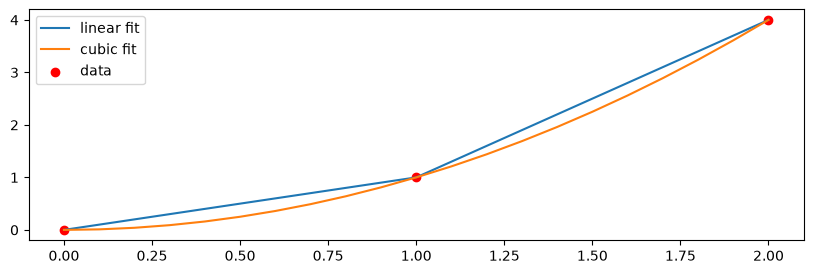

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(x_new,y_linear, label='linear fit')
plt.plot(x_new,y_cubic, label ='cubic fit')
plt.scatter(x,y, color = 'red', label='data')
plt.legend()

# Comprehensive Exercise: Analysis of Particle Motion

**Submission is optional**

In this exercise, we consider six particles moving in one dimension. Their positions are recorded at eight equally spaced time steps.

Some measurements are missing and are represented by `np.nan`.

The objective is to analyse the particle trajectories using NumPy and SciPy, applying array manipulation, indexing, Boolean operations, statistical functions, interpolation, vectorisation, and numerical integration.

Where possible, use NumPy operations instead of explicit Python loops.

## Initial data

The dataset contains the positions of six particles at eight time steps.

- Each row represents one particle.
- Each column represents a measurement time.
- Positions are measured in metres (m).
- Time is measured in seconds (s).


## Part A: Creating and inspecting arrays

1. Convert `trajectories` into a two-dimensional NumPy array.
2. Inspect the following attributes:
   - `ndim`: Number of dimensions.
   - `shape`: Shape of the array.
   - `size`: Total number of elements.
   - `dtype`: Data type of the elements.
3. Extract the complete trajectory of the third particle.
4. Extract the positions of all particles at the fourth time step.
5. Explain the difference between `axis=0` and `axis=1` for this dataset.


## Part B: Missing values and statistical analysis

1. Identify all missing measurements using `np.isnan()`.
2. Count the total number of missing measurements.
3. Calculate the mean position of the particles at each time step, ignoring missing values.
4. Calculate the mean measured position of each particle.
5. Determine the minimum and maximum measured positions.

**Hint:** Consider `np.nanmean()`, `np.nanmin()`, `np.nanmax()`, and the `axis` argument.


## Part C: Interpolation

Use interpolation to estimate the missing particle positions.

1. Identify the valid measurements for each particle.
2. Use `np.interp()` to estimate the missing positions by linear interpolation.
3. Store the completed trajectories in a new NumPy array.
4. Verify that the completed array contains no missing values.
5. Compare the original and interpolated trajectories.

**Hint:** `np.isnan()` identifies missing values, while `~np.isnan()` identifies valid values. You may use a loop over particles for this part.


## Part D: Velocity and vectorisation

The average velocity between consecutive measurements is

$$
v_i=\frac{x_{i+1}-x_i}{t_{i+1}-t_i}.
$$

1. Calculate the velocity of each particle between consecutive time steps using NumPy slicing.
2. Determine the mean velocity of each particle.
3. Compare the velocities of particles moving in the positive and negative directions.

**Hint:** Use `A[:, 1:]` and `A[:, :-1]` to obtain consecutive positions.



## Part E: Numerical integration

The displacement of a particle can be calculated by integrating its velocity:

$$
\Delta x=\int_{t_0}^{t_f}v(t)\,dt.
$$


1. Use the velocities calculated in Part D to estimate the displacement of each particle.
2. Calculate the displacement directly from the initial and final positions.
3. Compare the numerical and direct displacements.

**Hint:** The velocities from Part D are average velocities over intervals, not point measurements. Use

$$
\Delta x\approx\sum_i v_i\Delta t_i
$$

to calculate displacement consistently.

4. Use `np.trapezoid()` to integrate the interval-average velocities over their midpoint times and explain why this does not necessarily reproduce the full displacement.






In [ ]:
# i'll try this later :)